# Imports

In [3]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import pacmap
import pickle as pkl
from sklearn.decomposition import PCA

os.environ["GRB_LICENSE_FILE"] = "/Users/zohairshafi/gurobi.lic"
sys.path.append('/Users/zohairshafi/Local Workspace/forge')

from forge.embeddings import Forge
from forge.pipeline import pretrain, mip_to_embeddings

from forge.utils import Constants

# [Optional] Pre-Train Model if Needed

In [5]:
# Create Forge with training configuration
forge = Forge(train_config_yaml = "/Users/zohairshafi/Local Workspace/forge/forge/configs/train_config.yaml")

# Pre-train Forge
pretrain(forge=forge,
         input_mip_folder="/Users/zohairshafi/Local Workspace/forge/data/all_mip_data/",
         input_mip_instances_file="/Users/zohairshafi/Local Workspace/forge/data/configs/unit_test_instances.txt",
         output_mip_to_mipinfo_pkl="../models/unit_test_mip_to_mipinfo.pkl",
         output_forge_pretrained_pkl="../models/unit_test_forge_pretrained.pkl",
         output_log_file="../models/unit_test_forge_pretrained.log", 
         epochs=1)

 12%|█▏        | 17/141 [00:00<00:01, 78.72it/s]

 25%|██▍       | 35/141 [00:00<00:01, 80.82it/s]

 31%|███       | 44/141 [00:00<00:01, 73.63it/s]

 42%|████▏     | 59/141 [00:00<00:01, 62.35it/s]

 60%|█████▉    | 84/141 [00:01<00:00, 89.24it/s]

...

 82%|████████▏ | 115/141 [00:01<00:00, 41.47it/s]

 89%|████████▉ | 126/141 [00:02<00:00, 44.72it/s]

 96%|█████████▋| 136/141 [00:02<00:00, 45.83it/s]

100%|██████████| 141/141 [00:02<00:00, 56.34it/s]


Epoch:  0 | Loss on Instance 140 :  0.458 | Mean Loss : 1.228pace/forge/data/all_mip_data/DMIPLIB_GISP-medium_train_newgisp_erdos_renyi_55.mpss

------
Epoch: 0 | Mean Loss: 1.228+/-1.082 | Time For Epoch : 635.315s
------



# Generate Embeddings From Pre-Trained Model

In [5]:
forge = Forge(train_config_yaml = "/Users/zohairshafi/Local Workspace/forge/forge/configs/train_config.yaml")
mip_to_embeddings_dict = mip_to_embeddings(forge=forge,
                                           input_mips="/Users/zohairshafi/Local Workspace/forge/data/all_mip_data/",
                                           input_mip_instances_file="/Users/zohairshafi/Local Workspace/forge/data/configs/unit_test_instances.txt",
                                           input_forge_pkl="../models/unit_test_forge_pretrained.pkl",
                                           model_type=Constants.FORGE_PRE_TRAIN,
                                           output_mip_to_embeddings_pkl="../models/mip_to_embeddings.pkl")

<< Start: Generate embeddings: /Users/zohairshafi/Local Workspace/forge/data/all_mip_data/DMIPLIB_CA-medium_train_instance_605.lp
>> Finish: Generate embeddings: /Users/zohairshafi/Local Workspace/forge/data/all_mip_data/DMIPLIB_CA-medium_train_instance_605.lp
<< Start: Generate embeddings: /Users/zohairshafi/Local Workspace/forge/data/all_mip_data/DMIPLIB_GISP-easy_train_gisp_erdos_renyi_306.lp
>> Finish: Generate embeddings: /Users/zohairshafi/Local Workspace/forge/data/all_mip_data/DMIPLIB_GISP-easy_train_gisp_erdos_renyi_306.lp
<< Start: Generate embeddings: /Users/zohairshafi/Local Workspace/forge/data/all_mip_data/DMIPLIB_GISP-easy_train_gisp_erdos_renyi_246.lp
>> Finish: Generate embeddings: /Users/zohairshafi/Local Workspace/forge/data/all_mip_data/DMIPLIB_GISP-easy_train_gisp_erdos_renyi_246.lp
<< Start: Generate embeddings: /Users/zohairshafi/Local Workspace/forge/data/all_mip_data/DMIPLIB_GISP-easy_train_gisp_erdos_renyi_357.lp
>> Finish: Generate embeddings: /Users/zohairsh

# Visualize Embeddings

In [4]:
with open('../models/mip_to_embeddings.pkl', 'rb') as f:
    mip_to_embeddings_dict = pkl.load(f)

In [19]:
color_vec = [x.split('/')[-1].split('_')[1] for x in mip_to_embeddings_dict.keys()]
embed_mat = np.array([mip_to_embeddings_dict[key].instance_embedding for key in mip_to_embeddings_dict.keys()])
embed_mat = embed_mat / (embed_mat.sum(axis = 0) + 1e-10)

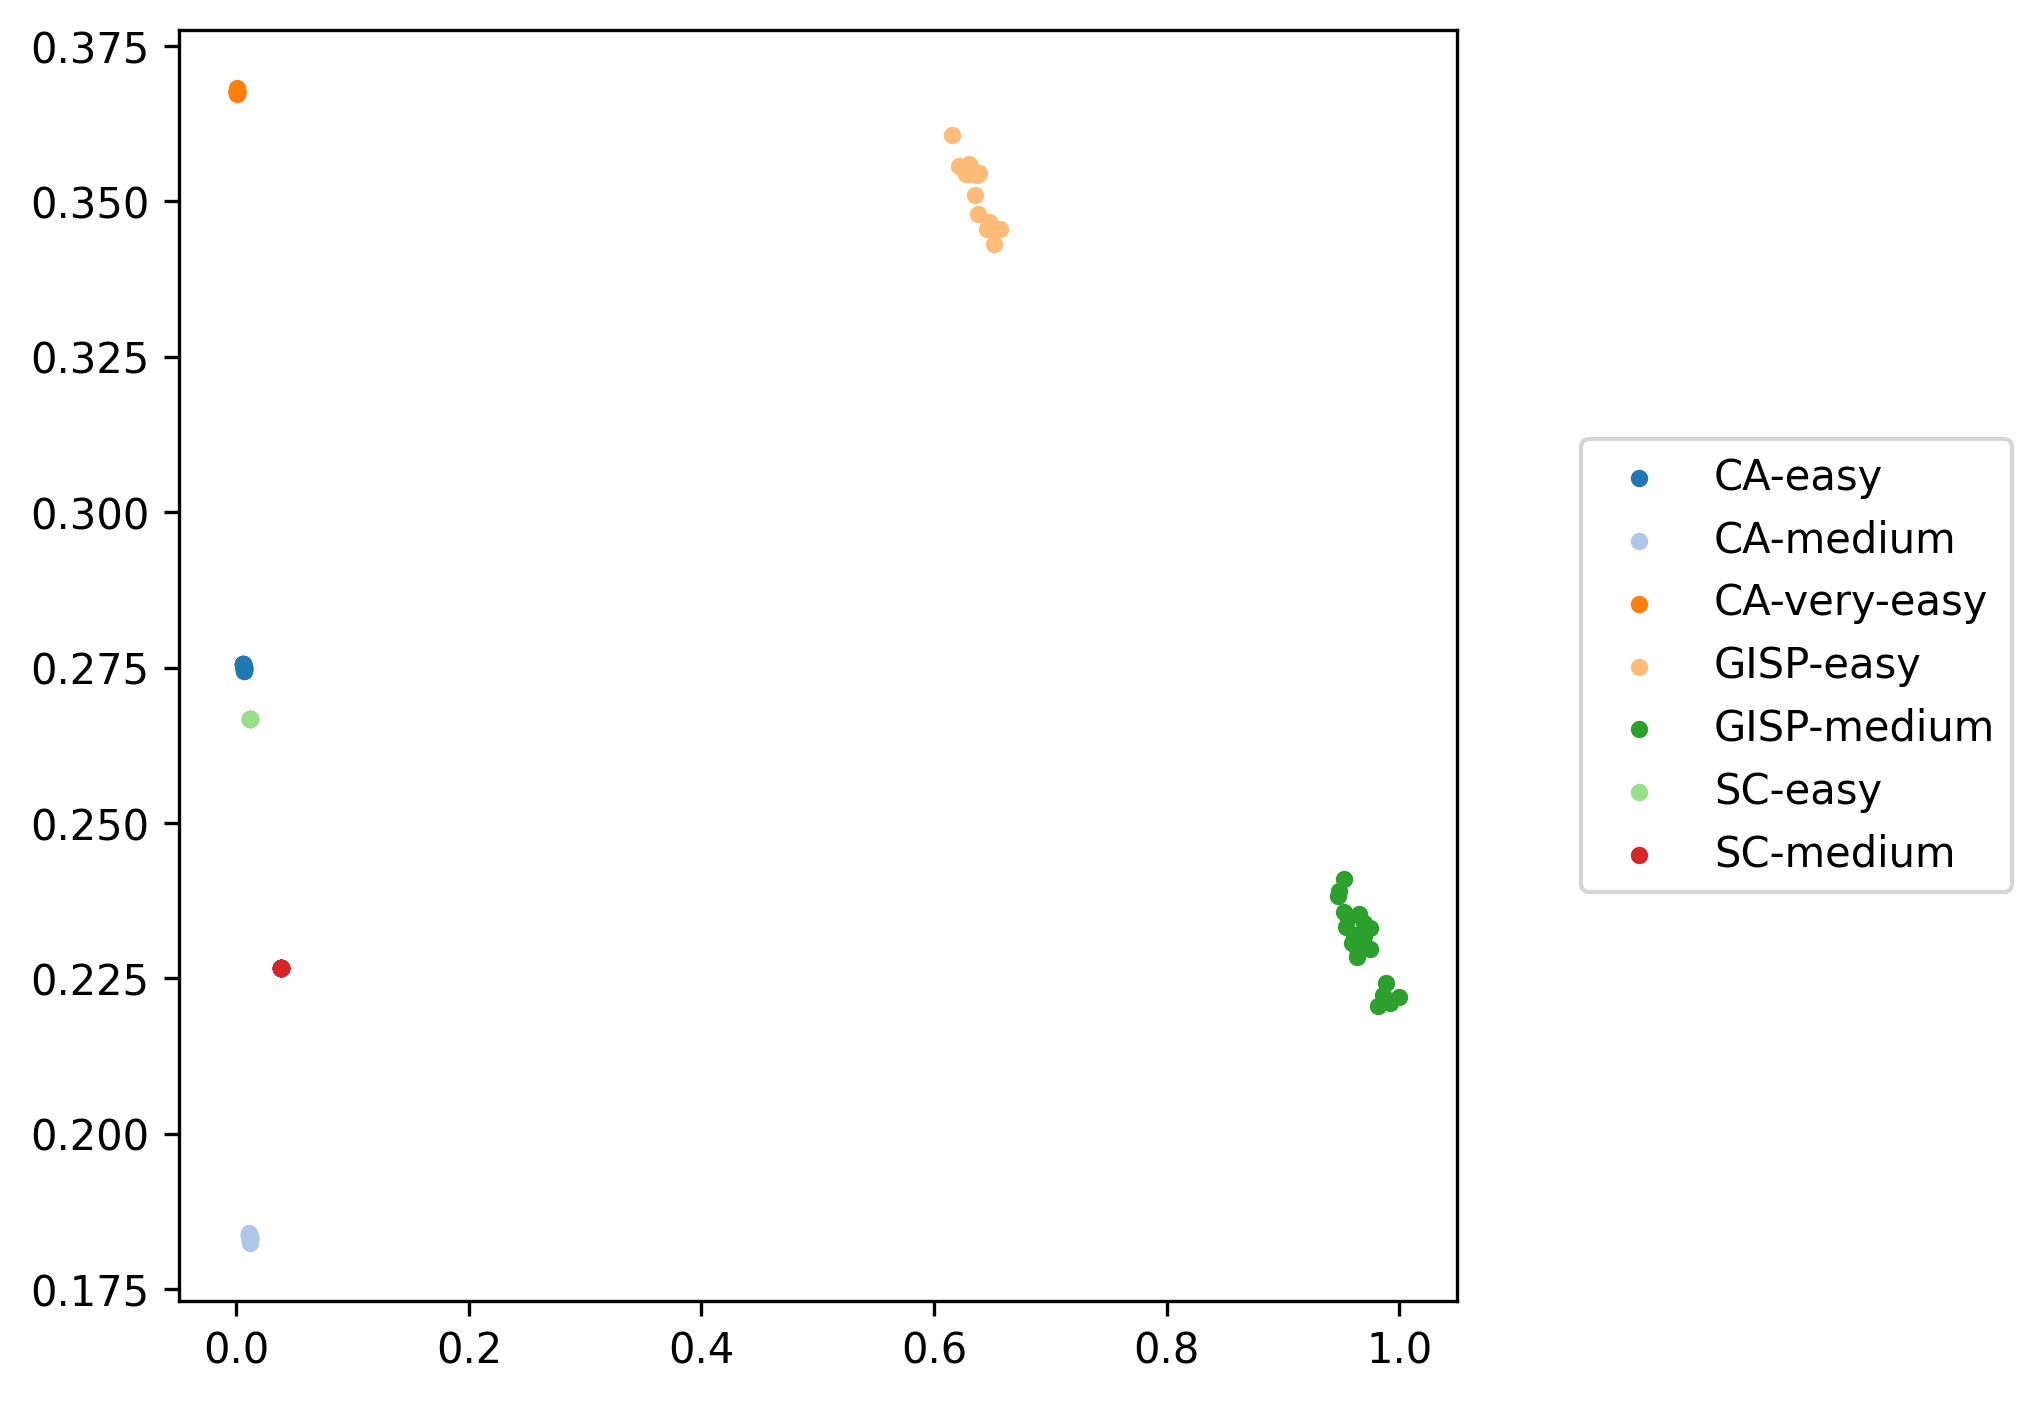

In [20]:
matrix_to_visualize = embed_mat

# Compute PCA to visualize in 2D
# pca = pacmap.PaCMAP(n_components = 2, n_neighbors=10, MN_ratio=0.5, FP_ratio=2.0).fit_transform(matrix_to_visualize, init = 'pca')
pca = PCA(n_components = 2).fit_transform(matrix_to_visualize)
pca = (pca - np.min(pca)) / np.ptp(pca)

# Compute an index dict to make it easier 
# to plot different labels and colors
index_dict = {}
for idx, c in enumerate(color_vec):
    try:
        index_dict[c].append(idx)
    except:
        index_dict[c] = [idx]

cmap = plt.get_cmap('tab20')
# Plot Instances 
plt.figure(figsize = (5.5, 5.5), dpi = 300)
for idx, c in enumerate(sorted(index_dict)):
    plt.scatter(pca[index_dict[c], 0] + np.random.rand()/1000, pca[index_dict[c], 1] + np.random.rand()/1000, s = 10, label = c, color = cmap(idx))
plt.legend(loc = 'right', ncols = 1, bbox_to_anchor = (1.45, .5))

plt.show()

# Cluster and NMI

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import normalized_mutual_info_score, adjusted_mutual_info_score
from sklearn.metrics.cluster import contingency_matrix

def purity_score(y_true, y_pred):
    """
    Used for Clustering Accuracy
    """

    # Compute contingency matrix (also called confusion matrix)
    con_matrix = contingency_matrix(y_true, y_pred)

    # Return purity
    return np.sum(np.amax(con_matrix, axis=0)) / np.sum(con_matrix)

In [ ]:
num_clusters = len(set(color_vec))
res_nmi = {'dist' : [], }
res_acc = {'dist' : [], }

for _ in range(10):
    
    km_dist = KMeans(n_clusters = num_clusters).fit(embed_mat)
    km_type = {'dist' : km_dist}

    for t in ['dist']:
        true = color_vec
        pred = km_type[t].labels_
        
        acc = {c : 0 for c in range(num_clusters)}
        names = {c : None for c in range(num_clusters)}
        for c in range(num_clusters):
            indices = np.where(pred == c)[0]
            acc[c] = purity_score(np.array(true)[indices], pred[indices])
            names[c] = set(np.array(true)[indices])
        
        nmi_score = normalized_mutual_info_score(true, pred)
        mean_acc = np.mean(list(acc.values()))
        res_acc[t].append(mean_acc)
        res_nmi[t].append(nmi_score)

for t in res_nmi.keys():
    print ("Results for clustering based on {}:".format(t))
    print (f"NMI: {np.mean(res_nmi[t]):.3f} | ACC: {np.mean(res_acc[t]):.3f}")